# 1. Project Overview

This notebook rebuilds cohort analysis from the processed datasets in `data/processed/`. The prior cohort notebook is treated only as a reference artifact; cohort definition, retention calculations, revenue analysis, visualizations, and business insights are derived from the available processed data.

The analysis follows customers from their signup month and measures monthly completed-transaction activity and revenue over time.

# 2. Import Libraries

The notebook uses production-oriented Python utilities for validation and logging, `pandas` and `numpy` for cohort calculations, and only `matplotlib` plus `seaborn` for visualization.

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

# 3. Configuration

All paths, logging settings, date handling, and output locations are declared centrally. Figures are saved to `outputs/figures/`; analytical tables and summaries are saved to `outputs/`.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CUSTOMER_ID_COLUMN = "customer_id"
COHORT_MONTH_COLUMN = "cohort_month"
ACTIVITY_MONTH_COLUMN = "activity_month"
COHORT_INDEX_COLUMN = "cohort_index"
REVENUE_COLUMN = "net_revenue"
COMPLETED_STATUS = "Completed"
MIN_OBSERVED_MONTHS_FOR_RANKING = 6

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger("cohort_analysis")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

# 4. Load Processed Data

Every cleaned CSV in `data/processed/` is discovered and loaded. The customer and transaction datasets are required for cohort analysis; the monthly aggregate table is retained only as supporting context.

In [3]:
def load_processed_csvs(data_dir: Path) -> Dict[str, pd.DataFrame]:
    """Load all processed CSV files from the configured directory."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Processed data directory not found: {data_dir}")

    csv_paths = sorted(data_dir.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No processed CSV files found in: {data_dir}")

    datasets: Dict[str, pd.DataFrame] = {}
    for path in csv_paths:
        try:
            datasets[path.name] = pd.read_csv(path)
            logger.info("Loaded %s with shape %s", path.name, datasets[path.name].shape)
        except Exception as exc:
            logger.exception("Failed to load %s", path.name)
            raise RuntimeError(f"Unable to load {path.name}") from exc
    return datasets


def find_dataset(
    datasets: Dict[str, pd.DataFrame],
    required_columns: Iterable[str],
    preferred_name: Optional[str] = None,
) -> Optional[pd.DataFrame]:
    """Return a copy of the dataset containing required columns."""
    required = set(required_columns)
    if preferred_name in datasets and required.issubset(datasets[preferred_name].columns):
        return datasets[preferred_name].copy()

    for data in datasets.values():
        if required.issubset(data.columns):
            return data.copy()
    return None


def build_dataset_inventory(datasets: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Create a compact inventory for all processed datasets."""
    records = []
    for name, data in datasets.items():
        records.append(
            {
                "dataset": name,
                "rows": data.shape[0],
                "columns": data.shape[1],
                "missing_values": int(data.isna().sum().sum()),
                "duplicate_rows": int(data.duplicated().sum()),
                "unique_customers": int(data[CUSTOMER_ID_COLUMN].nunique())
                if CUSTOMER_ID_COLUMN in data.columns
                else np.nan,
            }
        )
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)


processed_data = load_processed_csvs(DATA_DIR)
customers_raw = find_dataset(
    processed_data,
    required_columns=[CUSTOMER_ID_COLUMN, "signup_date"],
    preferred_name="financial_customers_clean.csv",
)
transactions_raw = find_dataset(
    processed_data,
    required_columns=[CUSTOMER_ID_COLUMN, "transaction_date"],
    preferred_name="financial_transactions_clean.csv",
)
monthly_raw = find_dataset(
    processed_data,
    required_columns=["year_month"],
    preferred_name="monthly_revenue_clean.csv",
)

if customers_raw is None:
    raise ValueError("A customer dataset with customer_id and signup_date is required.")
if transactions_raw is None:
    raise ValueError("A transaction dataset with customer_id and transaction_date is required.")

display(build_dataset_inventory(processed_data))

2026-07-08 21:45:17,210 - INFO - Loaded financial_customers_clean.csv with shape (20000, 36)
2026-07-08 21:45:18,082 - INFO - Loaded financial_transactions_clean.csv with shape (329202, 30)
2026-07-08 21:45:18,097 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


,dataset,rows,columns,missing_values,duplicate_rows,unique_customers
0,financial_customers_clean.csv,20000,36,0,0,20000.0000
1,financial_transactions_clean.csv,329202,30,0,0,20000.0000
2,monthly_revenue_clean.csv,36,18,0,0,NaN


# 5. Business Problem

The business needs to understand how customer groups acquired in different months retain activity and revenue over time. Cohort analysis answers which acquisition months created the most durable customer relationships, where retention decays fastest, and which cohorts deserve deeper operational review.

# 6. Cohort Definition

The selected cohort definition is **Customer Signup Month**.

This definition is best supported by the processed data because `signup_date` exists for every customer, `acquisition_month` matches signup month for every customer, and the transaction-level `cohort_month` also matches signup month for every customer. First transaction month is available through transactions, but it lags signup by one month for a small share of customers, so using first transaction month would shift some acquired customers into later cohorts and blur acquisition performance.

In [4]:
def to_month_start(series: pd.Series) -> pd.Series:
    """Convert a date-like series to month-start timestamps."""
    return pd.to_datetime(series, errors="coerce").dt.to_period("M").dt.to_timestamp()


def month_difference(later: pd.Series, earlier: pd.Series) -> pd.Series:
    """Calculate whole-month difference between two month-start series."""
    return (
        (later.dt.year - earlier.dt.year) * 12
        + (later.dt.month - earlier.dt.month)
    )


def evaluate_cohort_definitions(
    customers: pd.DataFrame,
    transactions: pd.DataFrame,
) -> pd.DataFrame:
    """Evaluate cohort definitions that are supported by the processed datasets."""
    customer_months = customers[[CUSTOMER_ID_COLUMN]].copy()
    customer_months["signup_month"] = to_month_start(customers["signup_date"])

    if "acquisition_month" in customers.columns:
        customer_months["acquisition_month"] = to_month_start(customers["acquisition_month"])

    transaction_dates = transactions.copy()
    transaction_dates["transaction_month"] = to_month_start(transaction_dates["transaction_date"])
    first_transaction_month = (
        transaction_dates.groupby(CUSTOMER_ID_COLUMN)["transaction_month"]
        .min()
        .rename("first_transaction_month")
        .reset_index()
    )
    customer_months = customer_months.merge(first_transaction_month, on=CUSTOMER_ID_COLUMN, how="left")

    if "cohort_month" in transactions.columns:
        transaction_cohort = (
            transactions.groupby(CUSTOMER_ID_COLUMN)["cohort_month"]
            .first()
            .pipe(to_month_start)
            .rename("transaction_cohort_month")
            .reset_index()
        )
        customer_months = customer_months.merge(transaction_cohort, on=CUSTOMER_ID_COLUMN, how="left")

    records = []
    records.append(
        {
            "candidate_definition": "Customer Signup Month",
            "source_column": "signup_date",
            "coverage_rate": customer_months["signup_month"].notna().mean(),
            "alignment_with_signup": 1.0,
            "selected": True,
            "reason": "Complete customer lifecycle anchor and aligned with acquisition fields.",
        }
    )

    if "acquisition_month" in customer_months.columns:
        records.append(
            {
                "candidate_definition": "Account Acquisition Month",
                "source_column": "acquisition_month",
                "coverage_rate": customer_months["acquisition_month"].notna().mean(),
                "alignment_with_signup": (
                    customer_months["acquisition_month"] == customer_months["signup_month"]
                ).mean(),
                "selected": False,
                "reason": "Equivalent to signup month in this dataset, so signup_date is more explicit.",
            }
        )

    records.append(
        {
            "candidate_definition": "First Transaction Month",
            "source_column": "transaction_date",
            "coverage_rate": customer_months["first_transaction_month"].notna().mean(),
            "alignment_with_signup": (
                customer_months["first_transaction_month"] == customer_months["signup_month"]
            ).mean(),
            "selected": False,
            "reason": "Supported, but some customers transact after signup month.",
        }
    )

    if "transaction_cohort_month" in customer_months.columns:
        records.append(
            {
                "candidate_definition": "Transaction Cohort Month",
                "source_column": "transactions.cohort_month",
                "coverage_rate": customer_months["transaction_cohort_month"].notna().mean(),
                "alignment_with_signup": (
                    customer_months["transaction_cohort_month"] == customer_months["signup_month"]
                ).mean(),
                "selected": False,
                "reason": "Matches signup month but is derived at transaction grain.",
            }
        )

    return pd.DataFrame(records)


cohort_definition_audit = evaluate_cohort_definitions(customers_raw, transactions_raw)
display(cohort_definition_audit)

,candidate_definition,source_column,coverage_rate,alignment_with_signup,selected,reason
0,Customer Signup Month,signup_date,1.0000,1.0000,True,Complete customer lifecycle anchor and aligned...
1,Account Acquisition Month,acquisition_month,1.0000,1.0000,False,"Equivalent to signup month in this dataset, so..."
2,First Transaction Month,transaction_date,1.0000,0.9724,False,"Supported, but some customers transact after s..."
3,Transaction Cohort Month,transactions.cohort_month,1.0000,1.0000,False,Matches signup month but is derived at transac...


# 7. Cohort Data Preparation

The customer table supplies cohort membership from signup month. The transaction table supplies monthly activity and revenue. A retained customer-month is defined as a customer with at least one completed transaction in that activity month; failed transactions are not treated as retained activity.

In [5]:
def build_customer_cohorts(customers: pd.DataFrame) -> pd.DataFrame:
    """Create one customer-to-cohort record per customer."""
    required_columns = {CUSTOMER_ID_COLUMN, "signup_date"}
    missing = required_columns.difference(customers.columns)
    if missing:
        raise ValueError(f"Customer data is missing required columns: {sorted(missing)}")

    cohort_base = customers[[CUSTOMER_ID_COLUMN, "signup_date"]].copy()
    cohort_base[COHORT_MONTH_COLUMN] = to_month_start(cohort_base["signup_date"])
    cohort_base = cohort_base.drop(columns=["signup_date"])

    if cohort_base[COHORT_MONTH_COLUMN].isna().any():
        raise ValueError("Some customer signup dates could not be parsed into cohort months.")

    return cohort_base.drop_duplicates(subset=[CUSTOMER_ID_COLUMN])


def prepare_monthly_activity(
    transactions: pd.DataFrame,
    customer_cohorts: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate completed transaction activity to customer-month grain."""
    required_columns = {CUSTOMER_ID_COLUMN, "transaction_date"}
    missing = required_columns.difference(transactions.columns)
    if missing:
        raise ValueError(f"Transaction data is missing required columns: {sorted(missing)}")

    activity = transactions.copy()
    if "transaction_status" in activity.columns:
        activity = activity[activity["transaction_status"].eq(COMPLETED_STATUS)].copy()

    activity[ACTIVITY_MONTH_COLUMN] = to_month_start(activity["transaction_date"])
    if REVENUE_COLUMN not in activity.columns:
        logger.warning("net_revenue is unavailable; revenue analysis will use zero values.")
        activity[REVENUE_COLUMN] = 0.0

    transaction_count_column = "transaction_id" if "transaction_id" in activity.columns else CUSTOMER_ID_COLUMN
    monthly_activity = (
        activity.groupby([CUSTOMER_ID_COLUMN, ACTIVITY_MONTH_COLUMN])
        .agg(
            monthly_net_revenue=(REVENUE_COLUMN, "sum"),
            monthly_transactions=(transaction_count_column, "count"),
        )
        .reset_index()
    )

    monthly_activity = monthly_activity.merge(customer_cohorts, on=CUSTOMER_ID_COLUMN, how="inner")
    monthly_activity = monthly_activity[
        monthly_activity[ACTIVITY_MONTH_COLUMN] >= monthly_activity[COHORT_MONTH_COLUMN]
    ].copy()
    return monthly_activity


customer_cohorts = build_customer_cohorts(customers_raw)
cohort_activity = prepare_monthly_activity(transactions_raw, customer_cohorts)
analysis_month = cohort_activity[ACTIVITY_MONTH_COLUMN].max()

print(f"Customer cohorts: {customer_cohorts[COHORT_MONTH_COLUMN].nunique():,}")
print(f"Activity months: {cohort_activity[ACTIVITY_MONTH_COLUMN].nunique():,}")
print(f"Analysis month: {analysis_month.date()}")
display(cohort_activity.head())

Customer cohorts: 35
Activity months: 36
Analysis month: 2024-12-01


,customer_id,activity_month,monthly_net_revenue,monthly_transactions,cohort_month
0,CUST_000000,2023-08-01,4856.7800,1,2023-07-01
1,CUST_000000,2023-09-01,5394.1900,1,2023-07-01
2,CUST_000000,2023-10-01,5457.9100,1,2023-07-01
3,CUST_000000,2023-11-01,6221.8200,1,2023-07-01
4,CUST_000000,2024-01-01,4732.4300,1,2023-07-01


# 8. Cohort Index Calculation

The cohort index measures each activity month relative to the customer's signup cohort month. Index `1` is the signup month, index `2` is the month after signup, and so on.

In [6]:
def add_cohort_index(activity: pd.DataFrame) -> pd.DataFrame:
    """Add a one-based cohort index to customer-month activity."""
    output = activity.copy()
    output[COHORT_INDEX_COLUMN] = (
        month_difference(output[ACTIVITY_MONTH_COLUMN], output[COHORT_MONTH_COLUMN]) + 1
    ).astype(int)
    output = output[output[COHORT_INDEX_COLUMN] >= 1].copy()
    return output


cohort_activity = add_cohort_index(cohort_activity)

cohort_index_summary = pd.DataFrame(
    [
        {
            "minimum_cohort_index": int(cohort_activity[COHORT_INDEX_COLUMN].min()),
            "maximum_cohort_index": int(cohort_activity[COHORT_INDEX_COLUMN].max()),
            "customer_month_rows": len(cohort_activity),
            "total_completed_transactions": int(cohort_activity["monthly_transactions"].sum()),
            "total_completed_net_revenue": float(cohort_activity["monthly_net_revenue"].sum()),
        }
    ]
)
display(cohort_index_summary)
display(
    cohort_activity[
        [
            CUSTOMER_ID_COLUMN,
            COHORT_MONTH_COLUMN,
            ACTIVITY_MONTH_COLUMN,
            COHORT_INDEX_COLUMN,
            "monthly_net_revenue",
            "monthly_transactions",
        ]
    ].head()
)

,minimum_cohort_index,maximum_cohort_index,customer_month_rows,total_completed_transactions,total_completed_net_revenue
0,1,35,200263,309523,527684244.2900


,customer_id,cohort_month,activity_month,cohort_index,monthly_net_revenue,monthly_transactions
0,CUST_000000,2023-07-01,2023-08-01,2,4856.7800,1
1,CUST_000000,2023-07-01,2023-09-01,3,5394.1900,1
2,CUST_000000,2023-07-01,2023-10-01,4,5457.9100,1
3,CUST_000000,2023-07-01,2023-11-01,5,6221.8200,1
4,CUST_000000,2023-07-01,2024-01-01,7,4732.4300,1


# 9. Customer Retention Matrix

Customer retention is calculated as active customers in each cohort index divided by total customers who signed up in that cohort month. Future, not-yet-observed months remain blank rather than zero.

In [7]:
def build_observed_cohort_grid(
    cohort_base: pd.DataFrame,
    latest_activity_month: pd.Timestamp,
) -> pd.DataFrame:
    """Build all observable cohort/index combinations up to the analysis month."""
    cohort_sizes = (
        cohort_base.groupby(COHORT_MONTH_COLUMN)[CUSTOMER_ID_COLUMN]
        .nunique()
        .rename("cohort_size")
        .reset_index()
    )
    grid_records = []
    for _, row in cohort_sizes.iterrows():
        max_index = int(
            (latest_activity_month.year - row[COHORT_MONTH_COLUMN].year) * 12
            + (latest_activity_month.month - row[COHORT_MONTH_COLUMN].month)
            + 1
        )
        for cohort_index in range(1, max_index + 1):
            grid_records.append(
                {
                    COHORT_MONTH_COLUMN: row[COHORT_MONTH_COLUMN],
                    COHORT_INDEX_COLUMN: cohort_index,
                    "cohort_size": row["cohort_size"],
                }
            )
    return pd.DataFrame(grid_records)


def build_customer_retention_tables(
    activity: pd.DataFrame,
    cohort_base: pd.DataFrame,
    latest_activity_month: pd.Timestamp,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build active-customer count and retention-rate matrices."""
    observed_grid = build_observed_cohort_grid(cohort_base, latest_activity_month)
    active_counts = (
        activity.groupby([COHORT_MONTH_COLUMN, COHORT_INDEX_COLUMN])[CUSTOMER_ID_COLUMN]
        .nunique()
        .rename("active_customers")
        .reset_index()
    )

    retention_long = observed_grid.merge(
        active_counts,
        on=[COHORT_MONTH_COLUMN, COHORT_INDEX_COLUMN],
        how="left",
    )
    retention_long["active_customers"] = retention_long["active_customers"].fillna(0).astype(int)
    retention_long["retention_rate"] = (
        retention_long["active_customers"] / retention_long["cohort_size"]
    )

    retention_matrix = retention_long.pivot(
        index=COHORT_MONTH_COLUMN,
        columns=COHORT_INDEX_COLUMN,
        values="retention_rate",
    )
    active_customer_matrix = retention_long.pivot(
        index=COHORT_MONTH_COLUMN,
        columns=COHORT_INDEX_COLUMN,
        values="active_customers",
    )
    cohort_sizes = (
        observed_grid[[COHORT_MONTH_COLUMN, "cohort_size"]]
        .drop_duplicates()
        .sort_values(COHORT_MONTH_COLUMN)
        .reset_index(drop=True)
    )
    return retention_long, retention_matrix, active_customer_matrix, cohort_sizes


retention_long, retention_matrix, active_customer_matrix, cohort_sizes = build_customer_retention_tables(
    cohort_activity,
    customer_cohorts,
    analysis_month,
)

display((retention_matrix * 100).round(2).head())
display(cohort_sizes.head())

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01,88.8900,22.2200,72.2200,31.4800,61.1100,48.1500,48.1500,50.0000,48.1500,46.3000,42.5900,37.0400,53.7000,37.0400,42.5900,35.1900,51.8500,29.6300,48.1500,35.1900,50.0000,27.7800,40.7400,46.3000,38.8900,27.7800,38.8900,38.8900,35.1900,31.4800,40.7400,31.4800,31.4800,44.4400,18.5200,0.0000
2022-02-01,86.2600,23.6600,63.3600,48.8500,49.6200,45.0400,55.7300,47.3300,54.2000,46.5600,46.5600,45.0400,44.2700,50.3800,41.9800,43.5100,48.8500,43.5100,36.6400,39.6900,39.6900,43.5100,40.4600,34.3500,40.4600,38.9300,32.8200,38.1700,33.5900,32.0600,32.0600,33.5900,38.9300,29.7700,0.0000,NaN
2022-03-01,92.3900,22.8400,66.5000,46.1900,44.6700,53.3000,46.1900,47.7200,45.6900,48.7300,45.6900,44.1600,46.7000,43.6500,42.1300,37.0600,36.5500,48.2200,41.6200,45.1800,34.5200,41.1200,44.6700,35.5300,33.5000,41.1200,42.6400,33.5000,39.0900,39.5900,29.4400,48.7300,27.9200,0.0000,NaN,NaN
2022-04-01,94.7900,24.1700,67.3000,47.3900,52.1300,45.5000,52.1300,45.0200,48.8200,49.7600,39.8100,50.7100,38.3900,43.6000,43.1300,51.6600,44.5500,41.7100,39.3400,41.7100,43.1300,37.4400,45.0200,41.7100,44.5500,38.3900,42.6500,37.4400,41.2300,34.6000,43.1300,33.6500,0.0000,NaN,NaN,NaN
2022-05-01,94.3700,27.4600,67.9600,51.0600,52.1100,56.3400,47.5400,51.7600,53.8700,46.4800,47.5400,50.0000,47.8900,48.5900,46.8300,42.9600,49.6500,52.4600,46.1300,46.1300,47.5400,36.2700,46.1300,38.3800,49.3000,37.6800,44.7200,39.7900,39.4400,34.8600,43.6600,0.0000,NaN,NaN,NaN,NaN


,cohort_month,cohort_size
0,2022-01-01,54
1,2022-02-01,131
2,2022-03-01,197
3,2022-04-01,211
4,2022-05-01,284


# 10. Revenue Retention Matrix

Revenue retention is calculated from completed transaction net revenue by cohort index. Each cohort's monthly revenue is divided by its own signup-month revenue to show expansion or contraction relative to the starting month.

In [8]:
def build_revenue_retention_tables(
    activity: pd.DataFrame,
    observed_retention: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build revenue and revenue-retention matrices."""
    revenue_by_period = (
        activity.groupby([COHORT_MONTH_COLUMN, COHORT_INDEX_COLUMN])["monthly_net_revenue"]
        .sum()
        .rename("net_revenue")
        .reset_index()
    )
    revenue_long = observed_retention[
        [COHORT_MONTH_COLUMN, COHORT_INDEX_COLUMN]
    ].merge(
        revenue_by_period,
        on=[COHORT_MONTH_COLUMN, COHORT_INDEX_COLUMN],
        how="left",
    )
    revenue_long["net_revenue"] = revenue_long["net_revenue"].fillna(0.0)

    revenue_matrix = revenue_long.pivot(
        index=COHORT_MONTH_COLUMN,
        columns=COHORT_INDEX_COLUMN,
        values="net_revenue",
    )
    initial_revenue = revenue_matrix.get(1, pd.Series(index=revenue_matrix.index, dtype=float))
    revenue_retention_matrix = revenue_matrix.div(initial_revenue.replace(0, np.nan), axis=0)
    revenue_long = revenue_long.merge(
        initial_revenue.rename("initial_net_revenue"),
        on=COHORT_MONTH_COLUMN,
        how="left",
    )
    revenue_long["revenue_retention_rate"] = (
        revenue_long["net_revenue"] / revenue_long["initial_net_revenue"].replace(0, np.nan)
    )
    return revenue_long, revenue_matrix, revenue_retention_matrix


revenue_long, revenue_matrix, revenue_retention_matrix = build_revenue_retention_tables(
    cohort_activity,
    retention_long,
)

display(revenue_matrix.round(2).head())
display((revenue_retention_matrix * 100).round(2).head())

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01,33172.8800,13276.7400,27937.5100,5090.2100,39581.7500,22232.4600,21847.6900,13506.1200,26134.4000,28933.3700,25177.7400,20278.0100,31309.2000,25824.6100,15345.8500,17669.2300,36685.2100,20282.7600,37284.1500,33324.7100,23274.5300,22126.6000,45727.8900,43211.6200,29072.7500,17055.5300,37365.4900,32351.8200,37325.3800,37645.4400,27118.3200,41383.5900,25874.4100,55678.6800,14678.8500,0.0000
2022-02-01,119806.1800,20416.7400,85893.2000,76845.9900,67388.4800,54957.1500,95895.9700,52421.0400,96240.6300,87739.0200,80881.5000,40314.1300,151321.7800,59946.2200,86614.2000,48714.0000,109836.6500,73836.5400,82660.6900,70469.0600,84830.1600,136672.9700,78366.4100,70962.2700,103490.5400,71538.9000,81539.9600,92234.8700,67539.3400,90575.3300,94075.5200,79686.7400,133642.6600,77183.9900,0.0000,NaN
2022-03-01,112731.1400,22841.6300,100580.2000,70399.4100,81521.0300,67453.0800,72818.1300,93432.4100,97514.8000,95175.9600,68661.0300,87320.2000,60752.8100,84988.7000,64954.5100,63038.6300,71418.2000,68817.0400,85575.5700,76068.8400,89203.4600,103111.7500,94069.7600,66484.1400,72588.3600,94249.8600,85138.0600,91220.7400,129611.1600,65514.8100,94491.3400,150820.1400,100385.9000,0.0000,NaN,NaN
2022-04-01,247734.5100,62834.0900,213329.8700,101311.5200,153308.4600,112189.4800,193286.5100,105771.2300,181703.7900,136660.2600,105768.8900,145154.5000,116182.5700,164616.9000,163156.7300,175279.0900,160138.8300,148719.9600,209250.2300,159812.6800,206422.9200,112392.8000,200957.0400,163172.7400,228393.4100,173059.4000,263239.7300,120443.8300,260542.8500,184876.3500,240200.1700,216232.1100,0.0000,NaN,NaN,NaN
2022-05-01,319323.5900,94162.2400,238809.8400,188548.8000,219632.7000,263832.8500,241675.2700,177027.9800,186726.1300,179364.4700,174805.5600,197159.2800,264657.1700,212531.2500,228112.5700,182408.4900,235437.4700,315494.5600,289867.3100,336769.1900,226535.0200,219838.1600,204894.5400,273610.0700,263779.7800,304406.2300,208687.4800,296012.5300,272566.4100,283582.8400,375359.8300,0.0000,NaN,NaN,NaN,NaN


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01,100.0000,40.0200,84.2200,15.3400,119.3200,67.0200,65.8600,40.7100,78.7800,87.2200,75.9000,61.1300,94.3800,77.8500,46.2600,53.2600,110.5900,61.1400,112.3900,100.4600,70.1600,66.7000,137.8500,130.2600,87.6400,51.4100,112.6400,97.5200,112.5200,113.4800,81.7500,124.7500,78.0000,167.8400,44.2500,0.0000
2022-02-01,100.0000,17.0400,71.6900,64.1400,56.2500,45.8700,80.0400,43.7500,80.3300,73.2300,67.5100,33.6500,126.3100,50.0400,72.3000,40.6600,91.6800,61.6300,69.0000,58.8200,70.8100,114.0800,65.4100,59.2300,86.3800,59.7100,68.0600,76.9900,56.3700,75.6000,78.5200,66.5100,111.5500,64.4200,0.0000,NaN
2022-03-01,100.0000,20.2600,89.2200,62.4500,72.3100,59.8400,64.5900,82.8800,86.5000,84.4300,60.9100,77.4600,53.8900,75.3900,57.6200,55.9200,63.3500,61.0500,75.9100,67.4800,79.1300,91.4700,83.4500,58.9800,64.3900,83.6100,75.5200,80.9200,114.9700,58.1200,83.8200,133.7900,89.0500,0.0000,NaN,NaN
2022-04-01,100.0000,25.3600,86.1100,40.9000,61.8800,45.2900,78.0200,42.7000,73.3500,55.1600,42.6900,58.5900,46.9000,66.4500,65.8600,70.7500,64.6400,60.0300,84.4700,64.5100,83.3200,45.3700,81.1200,65.8700,92.1900,69.8600,106.2600,48.6200,105.1700,74.6300,96.9600,87.2800,0.0000,NaN,NaN,NaN
2022-05-01,100.0000,29.4900,74.7900,59.0500,68.7800,82.6200,75.6800,55.4400,58.4800,56.1700,54.7400,61.7400,82.8800,66.5600,71.4400,57.1200,73.7300,98.8000,90.7800,105.4600,70.9400,68.8400,64.1700,85.6800,82.6100,95.3300,65.3500,92.7000,85.3600,88.8100,117.5500,0.0000,NaN,NaN,NaN,NaN


# 11. Cohort Size Analysis

Cohort size shows the number of customers acquired in each signup month. This helps interpret retention because small cohorts can swing more sharply than larger cohorts.

2026-07-08 21:45:19,325 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-08 21:45:19,330 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


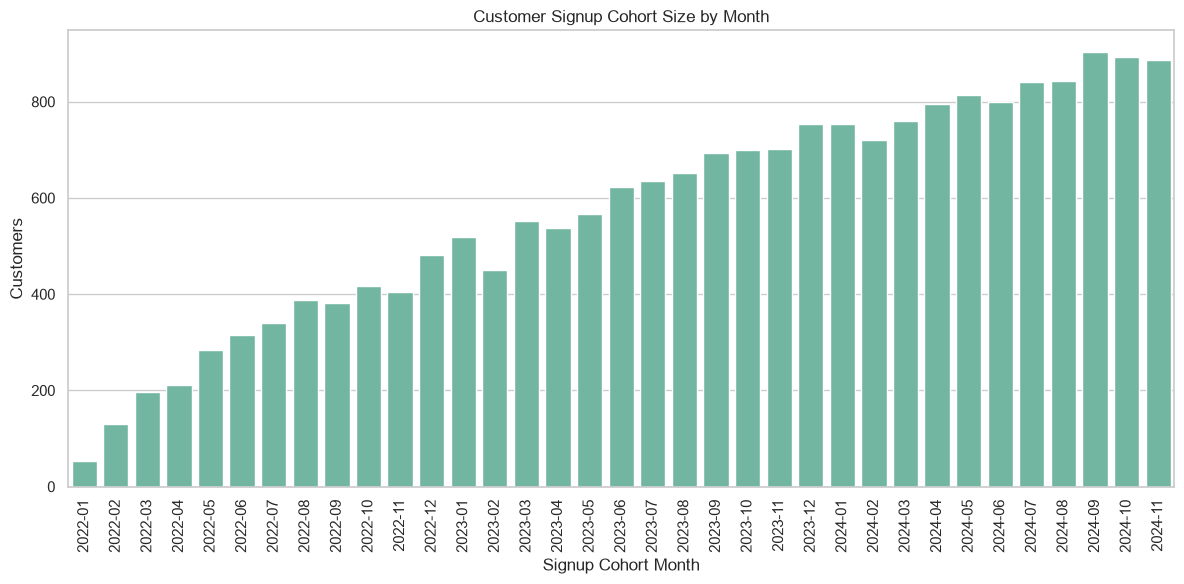

2026-07-08 21:45:19,706 - INFO - Cohort Size Analysis insight: The largest signup cohort was 2024-09 with 903 customers.


Business insight - Cohort Size Analysis: The largest signup cohort was 2024-09 with 903 customers.


In [9]:
cohort_size_plot = cohort_sizes.copy()
cohort_size_plot["cohort_month_label"] = cohort_size_plot[COHORT_MONTH_COLUMN].dt.strftime("%Y-%m")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    data=cohort_size_plot,
    x="cohort_month_label",
    y="cohort_size",
    ax=ax,
)
ax.set_title("Customer Signup Cohort Size by Month")
ax.set_xlabel("Signup Cohort Month")
ax.set_ylabel("Customers")
ax.tick_params(axis="x", rotation=90)

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "cohort_size_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

business_insights: List[Dict[str, str]] = []


def add_business_insight(section: str, insight: str) -> None:
    """Store and print an insight from a cohort analysis step."""
    business_insights.append({"section": section, "insight": insight})
    logger.info("%s insight: %s", section, insight)
    print(f"Business insight - {section}: {insight}")


largest_cohort = cohort_size_plot.sort_values("cohort_size", ascending=False).iloc[0]
add_business_insight(
    "Cohort Size Analysis",
    f"The largest signup cohort was {largest_cohort['cohort_month_label']} "
    f"with {int(largest_cohort['cohort_size']):,} customers."
)

# 12. Retention Heatmap

The customer retention heatmap shows how each signup cohort retained completed-transaction activity across subsequent months.

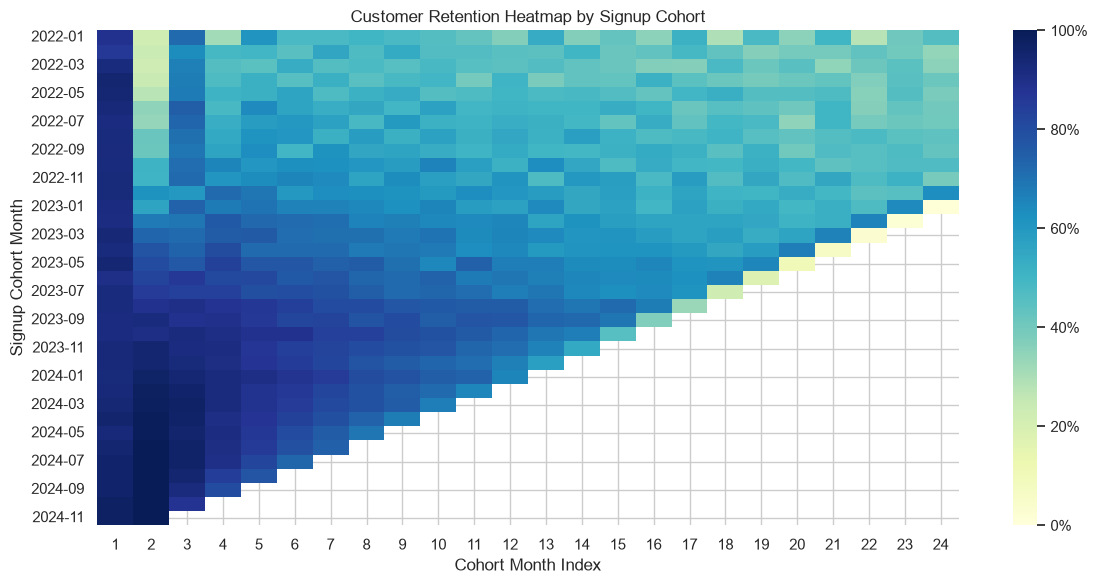

2026-07-08 21:45:20,060 - INFO - Retention Heatmap insight: Average signup-month retention is 93.1% across observed cohorts.


Business insight - Retention Heatmap: Average signup-month retention is 93.1% across observed cohorts.


In [10]:
retention_heatmap_data = retention_matrix.iloc[:, :24]
retention_heatmap_data.index = retention_heatmap_data.index.strftime("%Y-%m")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.heatmap(
    retention_heatmap_data,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"format": PercentFormatter(1.0)},
    ax=ax,
)
ax.set_title("Customer Retention Heatmap by Signup Cohort")
ax.set_xlabel("Cohort Month Index")
ax.set_ylabel("Signup Cohort Month")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

average_month_one_retention = retention_matrix[1].mean()
add_business_insight(
    "Retention Heatmap",
    f"Average signup-month retention is {average_month_one_retention:.1%} across observed cohorts."
)

# 13. Revenue Cohort Analysis

Revenue cohort analysis evaluates how each signup cohort's completed-transaction net revenue changes relative to its first month. This section includes both a revenue-retention heatmap and an average revenue-retention trend.

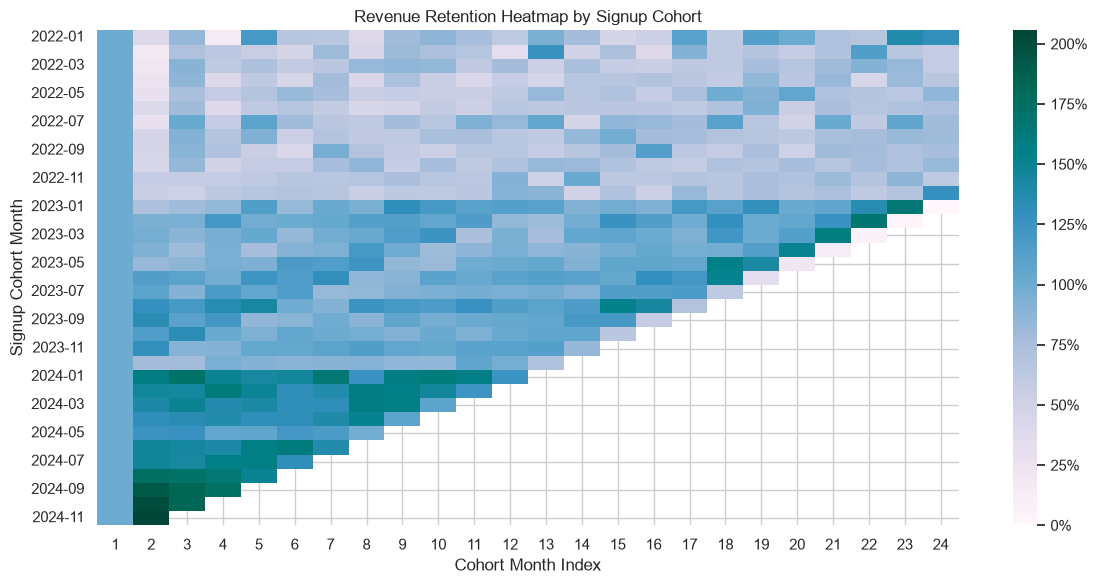

2026-07-08 21:45:20,417 - INFO - Revenue Cohort Analysis insight: Average first-month revenue retention is 100.0% by definition; later periods show the relative revenue durability of each cohort.


Business insight - Revenue Cohort Analysis: Average first-month revenue retention is 100.0% by definition; later periods show the relative revenue durability of each cohort.


In [11]:
revenue_heatmap_data = revenue_retention_matrix.iloc[:, :24]
revenue_heatmap_data.index = revenue_heatmap_data.index.strftime("%Y-%m")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.heatmap(
    revenue_heatmap_data,
    cmap="PuBuGn",
    vmin=0,
    cbar_kws={"format": PercentFormatter(1.0)},
    ax=ax,
)
ax.set_title("Revenue Retention Heatmap by Signup Cohort")
ax.set_xlabel("Cohort Month Index")
ax.set_ylabel("Signup Cohort Month")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "revenue_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

average_revenue_month_one = revenue_retention_matrix[1].mean()
add_business_insight(
    "Revenue Cohort Analysis",
    f"Average first-month revenue retention is {average_revenue_month_one:.1%} by definition; "
    "later periods show the relative revenue durability of each cohort."
)

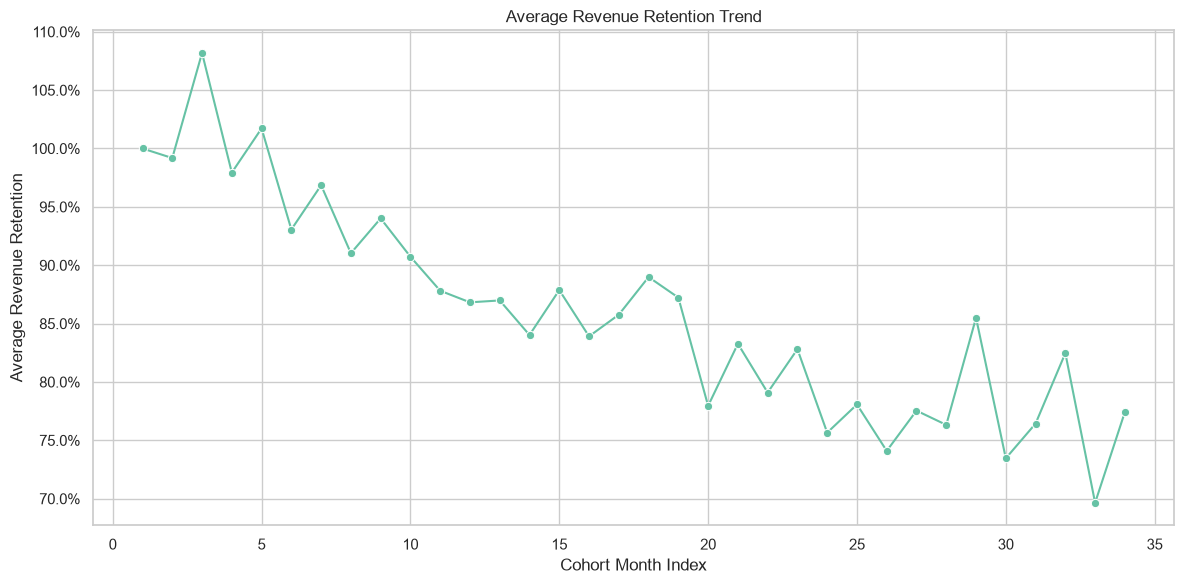

2026-07-08 21:45:20,658 - INFO - Revenue Retention Trend insight: At month index 34, average revenue retention is 77.4% across 3 observed cohorts.


Business insight - Revenue Retention Trend: At month index 34, average revenue retention is 77.4% across 3 observed cohorts.


In [12]:
revenue_retention_trend = (
    revenue_retention_matrix.mean(axis=0, skipna=True)
    .rename("average_revenue_retention")
    .reset_index()
)
revenue_retention_trend["observed_cohorts"] = revenue_retention_matrix.notna().sum(axis=0).values
revenue_retention_trend = revenue_retention_trend.rename(columns={COHORT_INDEX_COLUMN: "cohort_index"})
revenue_retention_trend = revenue_retention_trend[revenue_retention_trend["observed_cohorts"] >= 3]

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.lineplot(
    data=revenue_retention_trend,
    x="cohort_index",
    y="average_revenue_retention",
    marker="o",
    ax=ax,
)
ax.set_title("Average Revenue Retention Trend")
ax.set_xlabel("Cohort Month Index")
ax.set_ylabel("Average Revenue Retention")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "revenue_retention_trend.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

latest_revenue_trend = revenue_retention_trend.sort_values("cohort_index").iloc[-1]
add_business_insight(
    "Revenue Retention Trend",
    f"At month index {int(latest_revenue_trend['cohort_index'])}, average revenue retention is "
    f"{latest_revenue_trend['average_revenue_retention']:.1%} across "
    f"{int(latest_revenue_trend['observed_cohorts'])} observed cohorts."
)

# 14. Monthly Retention Trend

The monthly retention trend averages customer retention across all cohorts with enough observed history for each index. It highlights the typical lifecycle decay pattern after signup.

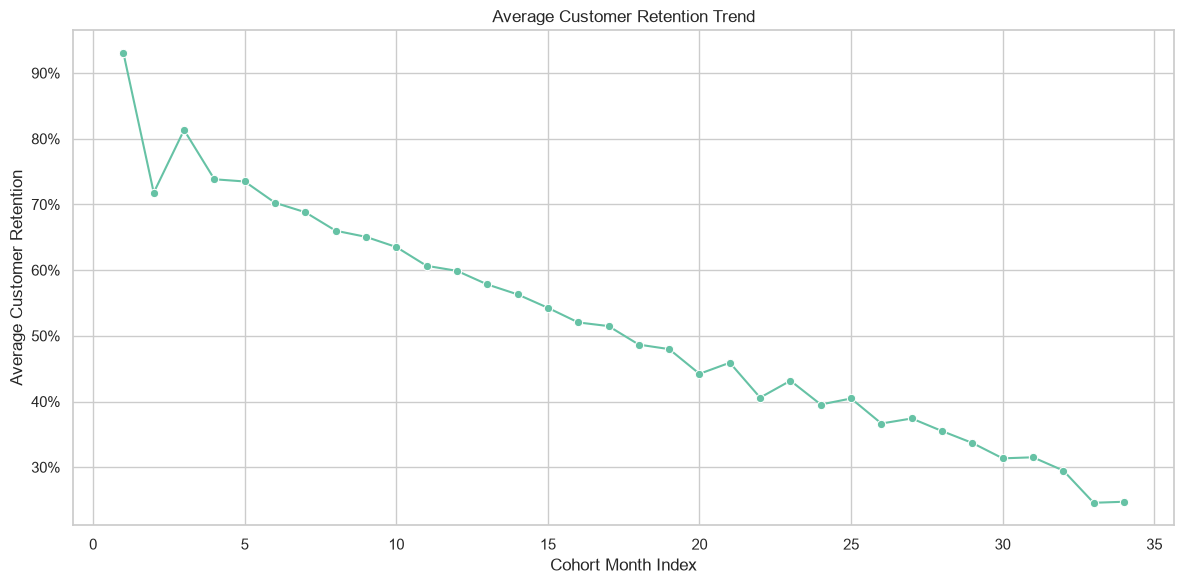

2026-07-08 21:45:20,879 - INFO - Monthly Retention Trend insight: Average month-3 customer retention is 81.3%.


Business insight - Monthly Retention Trend: Average month-3 customer retention is 81.3%.


In [13]:
monthly_retention_trend = (
    retention_matrix.mean(axis=0, skipna=True)
    .rename("average_customer_retention")
    .reset_index()
)
monthly_retention_trend["observed_cohorts"] = retention_matrix.notna().sum(axis=0).values
monthly_retention_trend = monthly_retention_trend.rename(columns={COHORT_INDEX_COLUMN: "cohort_index"})
monthly_retention_trend = monthly_retention_trend[monthly_retention_trend["observed_cohorts"] >= 3]

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.lineplot(
    data=monthly_retention_trend,
    x="cohort_index",
    y="average_customer_retention",
    marker="o",
    ax=ax,
)
ax.set_title("Average Customer Retention Trend")
ax.set_xlabel("Cohort Month Index")
ax.set_ylabel("Average Customer Retention")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "monthly_retention_trend.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

month_three = monthly_retention_trend[monthly_retention_trend["cohort_index"].eq(3)]
if not month_three.empty:
    insight_value = month_three.iloc[0]["average_customer_retention"]
    insight_text = f"Average month-3 customer retention is {insight_value:.1%}."
else:
    insight_text = "Not enough observed cohorts are available for month-3 retention."
add_business_insight("Monthly Retention Trend", insight_text)

# 15. Cohort Performance Comparison

Cohort performance is compared using observed average customer retention, cohort size, and total completed-transaction net revenue. Newer cohorts have less history, so observed months are retained in the summary.

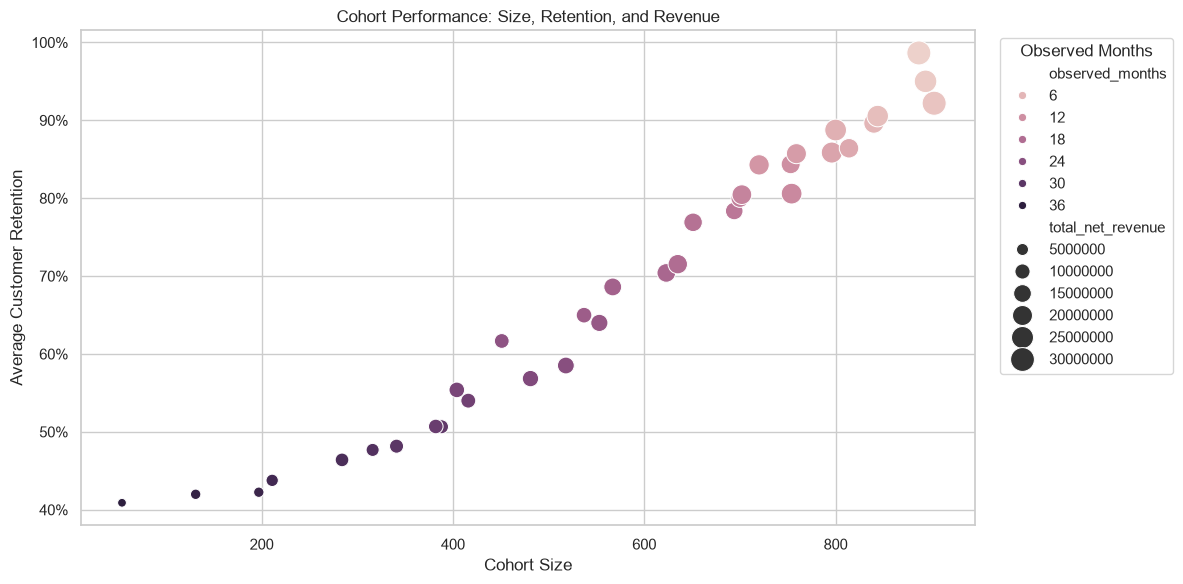

2026-07-08 21:45:21,308 - INFO - Cohort Performance Comparison insight: 2024-11 has the highest observed average customer retention at 98.6%.


Business insight - Cohort Performance Comparison: 2024-11 has the highest observed average customer retention at 98.6%.


,cohort_month,cohort_size,month_1_retention,month_3_retention,month_6_retention,month_12_retention,average_customer_retention,latest_customer_retention,observed_months,initial_net_revenue,total_net_revenue,average_revenue_retention,latest_revenue_retention,cohort_month_label
0,2022-01-01,54,0.8889,0.7222,0.4815,0.3704,0.4090,0.0000,36,33172.8800,984785.5000,0.8246,0.0000,2022-01
1,2022-02-01,131,0.8626,0.6336,0.4504,0.4504,0.4198,0.0000,35,119806.1800,2824538.8300,0.6736,0.0000,2022-02
2,2022-03-01,197,0.9239,0.6650,0.5330,0.4416,0.4225,0.0000,34,112731.1400,2782952.8000,0.7261,0.0000,2022-03
3,2022-04-01,211,0.9479,0.6730,0.4550,0.5071,0.4377,0.0000,33,247734.5100,5426143.4500,0.6637,0.0000,2022-04
4,2022-05-01,284,0.9437,0.6796,0.5634,0.5000,0.4640,0.0000,32,319323.5900,7475619.6100,0.7316,0.0000,2022-05


In [14]:
def last_valid_value(row: pd.Series) -> float:
    """Return the last non-null value from a row."""
    valid_values = row.dropna()
    if valid_values.empty:
        return np.nan
    return float(valid_values.iloc[-1])


def build_cohort_summary(
    sizes: pd.DataFrame,
    retention: pd.DataFrame,
    revenue: pd.DataFrame,
    revenue_retention: pd.DataFrame,
) -> pd.DataFrame:
    """Build one analytical summary row per cohort."""
    summary = sizes.set_index(COHORT_MONTH_COLUMN).copy()
    summary["month_1_retention"] = retention.get(1)
    summary["month_3_retention"] = retention.get(3)
    summary["month_6_retention"] = retention.get(6)
    summary["month_12_retention"] = retention.get(12)
    summary["average_customer_retention"] = retention.mean(axis=1, skipna=True)
    summary["latest_customer_retention"] = retention.apply(last_valid_value, axis=1)
    summary["observed_months"] = retention.notna().sum(axis=1)
    summary["initial_net_revenue"] = revenue.get(1)
    summary["total_net_revenue"] = revenue.sum(axis=1, skipna=True)
    summary["average_revenue_retention"] = revenue_retention.mean(axis=1, skipna=True)
    summary["latest_revenue_retention"] = revenue_retention.apply(last_valid_value, axis=1)
    summary = summary.reset_index()
    summary["cohort_month_label"] = summary[COHORT_MONTH_COLUMN].dt.strftime("%Y-%m")
    return summary.sort_values(COHORT_MONTH_COLUMN).reset_index(drop=True)


cohort_summary = build_cohort_summary(
    cohort_sizes,
    retention_matrix,
    revenue_matrix,
    revenue_retention_matrix,
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.scatterplot(
    data=cohort_summary,
    x="cohort_size",
    y="average_customer_retention",
    size="total_net_revenue",
    hue="observed_months",
    sizes=(40, 300),
    ax=ax,
)
ax.set_title("Cohort Performance: Size, Retention, and Revenue")
ax.set_xlabel("Cohort Size")
ax.set_ylabel("Average Customer Retention")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="Observed Months", bbox_to_anchor=(1.02, 1), loc="upper left")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "cohort_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

best_average = cohort_summary.sort_values("average_customer_retention", ascending=False).iloc[0]
add_business_insight(
    "Cohort Performance Comparison",
    f"{best_average['cohort_month_label']} has the highest observed average customer retention "
    f"at {best_average['average_customer_retention']:.1%}."
)

display(cohort_summary.head())

# 16. Best & Worst Performing Cohorts

Best and worst cohorts are ranked by average customer retention. Cohorts with at least six observed months are prioritized for ranking so very new cohorts do not dominate the comparison.

2026-07-08 21:45:21,327 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-08 21:45:21,329 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


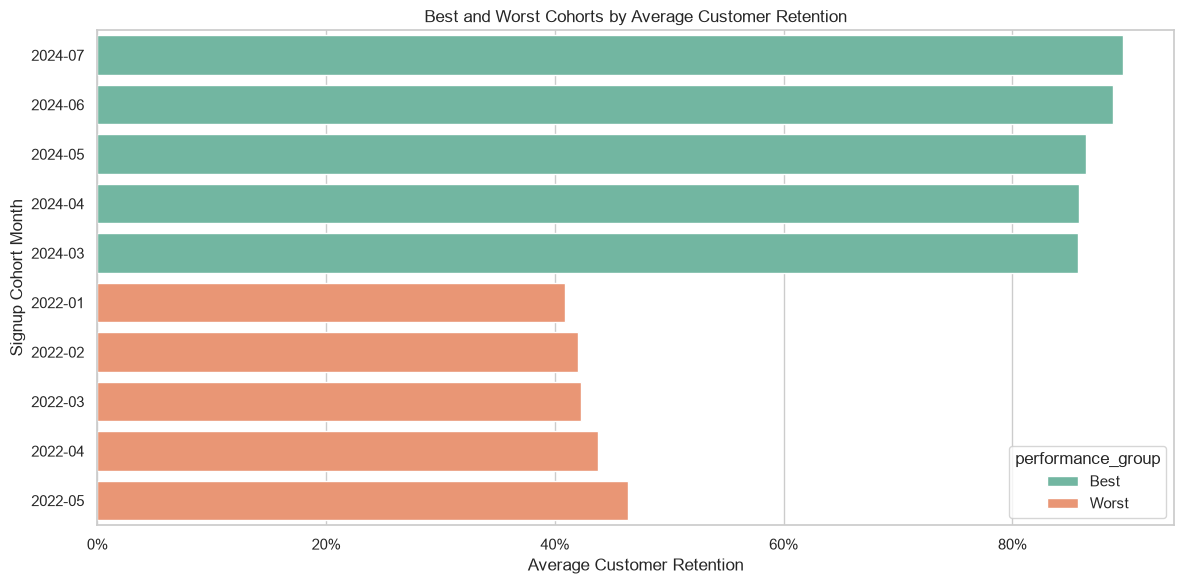

2026-07-08 21:45:21,579 - INFO - Best and Worst Cohorts insight: Among cohorts with sufficient history, 2024-07 leads retention while 2022-01 has the weakest average retention.


Business insight - Best and Worst Cohorts: Among cohorts with sufficient history, 2024-07 leads retention while 2022-01 has the weakest average retention.


,cohort_month,cohort_size,month_1_retention,month_3_retention,month_6_retention,month_12_retention,average_customer_retention,latest_customer_retention,observed_months,initial_net_revenue,total_net_revenue,average_revenue_retention,latest_revenue_retention,cohort_month_label
30,2024-07-01,840,0.9583,0.9643,0.7333,NaN,0.8964,0.7333,6,2475474.3300,20675909.3300,1.3921,1.3094,2024-07
29,2024-06-01,800,0.9500,0.9613,0.7925,NaN,0.8875,0.7425,7,2467111.8200,24416786.5900,1.4138,1.3801,2024-06
28,2024-05-01,814,0.9312,0.9570,0.8071,NaN,0.8641,0.6916,8,2101572.5000,18916511.8200,1.1251,0.9727,2024-05
27,2024-04-01,796,0.9560,0.9623,0.8329,NaN,0.8586,0.6721,9,1944293.5000,22654050.2900,1.2946,1.0805,2024-04
26,2024-03-01,759,0.9381,0.9697,0.8524,NaN,0.8572,0.6693,10,1491456.3800,20200073.5000,1.3544,1.0765,2024-03


,cohort_month,cohort_size,month_1_retention,month_3_retention,month_6_retention,month_12_retention,average_customer_retention,latest_customer_retention,observed_months,initial_net_revenue,total_net_revenue,average_revenue_retention,latest_revenue_retention,cohort_month_label
0,2022-01-01,54,0.8889,0.7222,0.4815,0.3704,0.4090,0.0000,36,33172.8800,984785.5000,0.8246,0.0000,2022-01
1,2022-02-01,131,0.8626,0.6336,0.4504,0.4504,0.4198,0.0000,35,119806.1800,2824538.8300,0.6736,0.0000,2022-02
2,2022-03-01,197,0.9239,0.6650,0.5330,0.4416,0.4225,0.0000,34,112731.1400,2782952.8000,0.7261,0.0000,2022-03
3,2022-04-01,211,0.9479,0.6730,0.4550,0.5071,0.4377,0.0000,33,247734.5100,5426143.4500,0.6637,0.0000,2022-04
4,2022-05-01,284,0.9437,0.6796,0.5634,0.5000,0.4640,0.0000,32,319323.5900,7475619.6100,0.7316,0.0000,2022-05


In [15]:
eligible_cohorts = cohort_summary[
    cohort_summary["observed_months"] >= MIN_OBSERVED_MONTHS_FOR_RANKING
].copy()
if eligible_cohorts.empty:
    eligible_cohorts = cohort_summary.copy()

best_cohorts = eligible_cohorts.sort_values("average_customer_retention", ascending=False).head(5)
worst_cohorts = eligible_cohorts.sort_values("average_customer_retention", ascending=True).head(5)

best_worst_plot = pd.concat(
    [
        best_cohorts.assign(performance_group="Best"),
        worst_cohorts.assign(performance_group="Worst"),
    ],
    ignore_index=True,
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    data=best_worst_plot,
    x="average_customer_retention",
    y="cohort_month_label",
    hue="performance_group",
    ax=ax,
)
ax.set_title("Best and Worst Cohorts by Average Customer Retention")
ax.set_xlabel("Average Customer Retention")
ax.set_ylabel("Signup Cohort Month")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "best_worst_cohorts.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

best_label = best_cohorts.iloc[0]["cohort_month_label"]
worst_label = worst_cohorts.iloc[0]["cohort_month_label"]
add_business_insight(
    "Best and Worst Cohorts",
    f"Among cohorts with sufficient history, {best_label} leads retention while "
    f"{worst_label} has the weakest average retention."
)

display(best_cohorts)
display(worst_cohorts)

# 17. Retention KPIs

Retention KPIs summarize the overall cohort system, including customer counts, average retention at important lifecycle points, and revenue durability.

In [16]:
def safe_get_average(matrix: pd.DataFrame, column: int) -> float:
    """Return a column average from a matrix when the column exists."""
    if column not in matrix.columns:
        return np.nan
    return float(matrix[column].mean(skipna=True))


retention_kpis = pd.DataFrame(
    [
        {
            "total_customers": int(cohort_sizes["cohort_size"].sum()),
            "total_cohorts": int(cohort_sizes[COHORT_MONTH_COLUMN].nunique()),
            "analysis_month": analysis_month.strftime("%Y-%m"),
            "average_month_1_retention": safe_get_average(retention_matrix, 1),
            "average_month_3_retention": safe_get_average(retention_matrix, 3),
            "average_month_6_retention": safe_get_average(retention_matrix, 6),
            "average_month_12_retention": safe_get_average(retention_matrix, 12),
            "average_observed_retention": float(cohort_summary["average_customer_retention"].mean()),
            "average_observed_revenue_retention": float(cohort_summary["average_revenue_retention"].mean()),
            "total_completed_net_revenue": float(revenue_matrix.sum().sum()),
            "best_cohort_by_retention": best_cohorts.iloc[0]["cohort_month_label"],
            "worst_cohort_by_retention": worst_cohorts.iloc[0]["cohort_month_label"],
        }
    ]
)

display(retention_kpis)

,total_customers,total_cohorts,analysis_month,average_month_1_retention,average_month_3_retention,average_month_6_retention,average_month_12_retention,average_observed_retention,average_observed_revenue_retention,total_completed_net_revenue,best_cohort_by_retention,worst_cohort_by_retention
0,20000,35,2024-12,0.9306,0.8134,0.7025,0.5989,0.6903,1.0442,527684244.2900,2024-07,2022-01


# 18. Business Insights

The following insights were generated from the cohort visualizations and analytical tables in this notebook.

In [17]:
business_insights_df = pd.DataFrame(business_insights)
display(business_insights_df)

,section,insight
0,Cohort Size Analysis,The largest signup cohort was 2024-09 with 903...
1,Retention Heatmap,Average signup-month retention is 93.1% across...
2,Revenue Cohort Analysis,Average first-month revenue retention is 100.0...
3,Revenue Retention Trend,"At month index 34, average revenue retention i..."
4,Monthly Retention Trend,Average month-3 customer retention is 81.3%.
5,Cohort Performance Comparison,2024-11 has the highest observed average custo...
6,Best and Worst Cohorts,"Among cohorts with sufficient history, 2024-07..."


# 19. Business Recommendations

Recommendations are based on the selected signup-month cohort definition, observed customer retention, revenue retention, and cohort-level performance differences.

In [18]:
def build_business_recommendations(
    kpis: pd.DataFrame,
    best: pd.DataFrame,
    worst: pd.DataFrame,
    trend: pd.DataFrame,
) -> List[str]:
    """Create dataset-backed cohort recommendations."""
    recommendations: List[str] = []
    kpi_row = kpis.iloc[0]

    recommendations.append(
        f"Study acquisition, onboarding, and customer profile patterns from the "
        f"{kpi_row['best_cohort_by_retention']} cohort because it has the strongest "
        "observed retention among cohorts with sufficient history."
    )
    recommendations.append(
        f"Review the {kpi_row['worst_cohort_by_retention']} cohort for onboarding friction, "
        "early product adoption issues, or acquisition-quality differences."
    )

    if not trend.empty and trend["cohort_index"].max() >= 3:
        month_three_value = trend.loc[
            trend["cohort_index"].eq(3),
            "average_customer_retention",
        ]
        if not month_three_value.empty:
            recommendations.append(
                f"Use month-3 retention of {month_three_value.iloc[0]:.1%} as an early-health "
                "checkpoint for new signup cohorts."
            )

    recommendations.append(
        "Track customer retention and revenue retention together; cohorts with stable customer "
        "counts but weaker revenue retention may need expansion or pricing review."
    )
    recommendations.append(
        "Refresh these cohort tables monthly after new transaction data is processed so retention "
        "trends are monitored with consistent methodology."
    )
    return recommendations


business_recommendations = build_business_recommendations(
    retention_kpis,
    best_cohorts,
    worst_cohorts,
    monthly_retention_trend,
)

for index, recommendation in enumerate(business_recommendations, start=1):
    print(f"{index}. {recommendation}")

business_recommendations_df = pd.DataFrame(
    {"recommendation": business_recommendations}
)

1. Study acquisition, onboarding, and customer profile patterns from the 2024-07 cohort because it has the strongest observed retention among cohorts with sufficient history.
2. Review the 2022-01 cohort for onboarding friction, early product adoption issues, or acquisition-quality differences.
3. Use month-3 retention of 81.3% as an early-health checkpoint for new signup cohorts.
4. Track customer retention and revenue retention together; cohorts with stable customer counts but weaker revenue retention may need expansion or pricing review.
5. Refresh these cohort tables monthly after new transaction data is processed so retention trends are monitored with consistent methodology.


# 20. Save Outputs

All analytical tables required for review and downstream reporting are exported to `outputs/`. This includes the customer retention matrix, revenue retention matrix, cohort summary, retention KPIs, trend tables, and business insight tables.

In [19]:
output_tables = {
    "cohort_definition_audit": cohort_definition_audit,
    "cohort_activity": cohort_activity,
    "cohort_sizes": cohort_sizes,
    "customer_retention_long": retention_long,
    "customer_retention_matrix": retention_matrix,
    "active_customer_matrix": active_customer_matrix,
    "revenue_long": revenue_long,
    "revenue_matrix": revenue_matrix,
    "revenue_retention_matrix": revenue_retention_matrix,
    "monthly_retention_trend": monthly_retention_trend,
    "revenue_retention_trend": revenue_retention_trend,
    "cohort_summary": cohort_summary,
    "best_cohorts": best_cohorts,
    "worst_cohorts": worst_cohorts,
    "retention_kpis": retention_kpis,
    "cohort_business_insights": business_insights_df,
    "cohort_business_recommendations": business_recommendations_df,
}

saved_output_records = []
for table_name, table in output_tables.items():
    output_path = OUTPUTS_DIR / f"{table_name}.csv"
    try:
        table.to_csv(output_path, index=True if table.index.name is not None else False)
        saved_output_records.append({"output": table_name, "path": output_path})
    except Exception as exc:
        logger.exception("Failed to save %s", table_name)
        raise RuntimeError(f"Unable to save output table: {table_name}") from exc

saved_outputs_df = pd.DataFrame(saved_output_records)
display(saved_outputs_df)
logger.info("Saved %s cohort analytical tables to %s", len(saved_outputs_df), OUTPUTS_DIR)

,output,path
0,cohort_definition_audit,/Users/ayushkumarsingh/Downloads/Financial-Ope...
1,cohort_activity,/Users/ayushkumarsingh/Downloads/Financial-Ope...
2,cohort_sizes,/Users/ayushkumarsingh/Downloads/Financial-Ope...
3,customer_retention_long,/Users/ayushkumarsingh/Downloads/Financial-Ope...
4,customer_retention_matrix,/Users/ayushkumarsingh/Downloads/Financial-Ope...
5,active_customer_matrix,/Users/ayushkumarsingh/Downloads/Financial-Ope...
6,revenue_long,/Users/ayushkumarsingh/Downloads/Financial-Ope...
7,revenue_matrix,/Users/ayushkumarsingh/Downloads/Financial-Ope...
8,revenue_retention_matrix,/Users/ayushkumarsingh/Downloads/Financial-Ope...
9,monthly_retention_trend,/Users/ayushkumarsingh/Downloads/Financial-Ope...


2026-07-08 21:45:21,984 - INFO - Saved 17 cohort analytical tables to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs


# 21. Executive Cohort Summary

The executive summary consolidates the selected cohort definition, cohort scale, retention KPIs, best and worst cohorts, and recommended actions. This final section also saves the text summary to `outputs/executive_cohort_summary.txt`.

In [20]:
def build_executive_summary() -> str:
    """Create a concise executive cohort summary."""
    kpi_row = retention_kpis.iloc[0]
    lines = [
        "Executive Cohort Summary",
        "========================",
        "Cohort definition: Customer Signup Month from signup_date.",
        "Definition rationale: signup_date exists for every customer and aligns with acquisition_month "
        "and transaction cohort_month across the processed datasets.",
        f"Customer base analyzed: {int(kpi_row['total_customers']):,}",
        f"Signup cohorts analyzed: {int(kpi_row['total_cohorts']):,}",
        f"Latest activity month: {kpi_row['analysis_month']}",
        f"Average month-1 customer retention: {kpi_row['average_month_1_retention']:.1%}",
        f"Average month-3 customer retention: {kpi_row['average_month_3_retention']:.1%}",
        f"Average month-6 customer retention: {kpi_row['average_month_6_retention']:.1%}",
        f"Average observed revenue retention: {kpi_row['average_observed_revenue_retention']:.1%}",
        f"Best cohort by retention: {kpi_row['best_cohort_by_retention']}",
        f"Weakest cohort by retention: {kpi_row['worst_cohort_by_retention']}",
        "Top recommendations:",
    ]
    lines.extend([f"- {recommendation}" for recommendation in business_recommendations[:5]])
    return "\n".join(lines)


executive_summary = build_executive_summary()
summary_path = OUTPUTS_DIR / "executive_cohort_summary.txt"
try:
    summary_path.write_text(executive_summary, encoding="utf-8")
except Exception as exc:
    logger.exception("Failed to save executive cohort summary.")
    raise RuntimeError("Unable to save executive cohort summary.") from exc

print(executive_summary)
logger.info("Saved executive cohort summary to %s", summary_path)

2026-07-08 21:45:21,991 - INFO - Saved executive cohort summary to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_cohort_summary.txt


Executive Cohort Summary
Cohort definition: Customer Signup Month from signup_date.
Definition rationale: signup_date exists for every customer and aligns with acquisition_month and transaction cohort_month across the processed datasets.
Customer base analyzed: 20,000
Signup cohorts analyzed: 35
Latest activity month: 2024-12
Average month-1 customer retention: 93.1%
Average month-3 customer retention: 81.3%
Average month-6 customer retention: 70.3%
Average observed revenue retention: 104.4%
Best cohort by retention: 2024-07
Weakest cohort by retention: 2022-01
Top recommendations:
- Study acquisition, onboarding, and customer profile patterns from the 2024-07 cohort because it has the strongest observed retention among cohorts with sufficient history.
- Review the 2022-01 cohort for onboarding friction, early product adoption issues, or acquisition-quality differences.
- Use month-3 retention of 81.3% as an early-health checkpoint for new signup cohorts.
- Track customer retention and